## 1.Import Libraries

In [164]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

## 2.Import Dataset

In [165]:
df = pd.read_csv('../data/raw/life_expectancy_raw.csv')

## 3.Data Cleaning

In [166]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2938 non-null   str    
 1   Year                          2938 non-null   int64  
 2   Status                        2938 non-null   str    
 3   Lifeexpectancy                2928 non-null   float64
 4   AdultMortality                2928 non-null   float64
 5   infantdeaths                  2938 non-null   int64  
 6   Alcohol                       2744 non-null   float64
 7   percentageexpenditure         2938 non-null   float64
 8   HepatitisB                    2385 non-null   float64
 9   Measles                       2938 non-null   int64  
 10  BMI                           2904 non-null   float64
 11  under-fivedeaths              2938 non-null   int64  
 12  Polio                         2919 non-null   float64
 13  Totalexpenditu

In [167]:
df.describe()

,Year,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [168]:
df.head()

,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [169]:
df.drop(columns=['thinness1-19years', 'thinness5-9years', 'Incomecompositionofresources','percentageexpenditure'], inplace=True)

In [170]:
df.rename(columns={'Alcohol': 'alcohol_consumption',
                   'HepatitisB':'HepatitisB_vaccine_coverage',
                   'Polio':'Polio_vaccine_coverage',
                   'Diphtheria':'Diphtheria_vaccine_coverage',
                   'Total_expenditure':'gov_expenditure_on_health',
                   }, inplace=True)

In [171]:
## Checking Complete Duplicated Rows 
total_duplicates = df.duplicated().sum()

print("\nTotal duplicated rows:")
print(total_duplicates)

duplicated_rows = df[df.duplicated(keep=False)]

print("\nDuplicated rows:")
display(duplicated_rows)


Total duplicated rows:
0

Duplicated rows:


,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,alcohol_consumption,HepatitisB_vaccine_coverage,Measles,BMI,under-fivedeaths,Polio_vaccine_coverage,Totalexpenditure,Diphtheria_vaccine_coverage,HIV/AIDS,GDP,Population,Schooling


In [172]:
# Checking incomplete duplicated rows
incomplete_duplicates = df.duplicated(subset=['Year','Country'],keep=False)
incomplete_duplicated_rows = df[incomplete_duplicates].sort_values(by=['Year','Country'])
display(incomplete_duplicated_rows)

,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,alcohol_consumption,HepatitisB_vaccine_coverage,Measles,BMI,under-fivedeaths,Polio_vaccine_coverage,Totalexpenditure,Diphtheria_vaccine_coverage,HIV/AIDS,GDP,Population,Schooling


In [173]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      2938 non-null   str    
 1   Year                         2938 non-null   int64  
 2   Status                       2938 non-null   str    
 3   Lifeexpectancy               2928 non-null   float64
 4   AdultMortality               2928 non-null   float64
 5   infantdeaths                 2938 non-null   int64  
 6   alcohol_consumption          2744 non-null   float64
 7   HepatitisB_vaccine_coverage  2385 non-null   float64
 8   Measles                      2938 non-null   int64  
 9   BMI                          2904 non-null   float64
 10  under-fivedeaths             2938 non-null   int64  
 11  Polio_vaccine_coverage       2919 non-null   float64
 12  Totalexpenditure             2712 non-null   float64
 13  Diphtheria_vaccine_coverage  

In [174]:
## Missing values
missing_values = df.isna().sum()
missing_percentage = df.isna().sum() / len(df) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": missing_percentage
}).sort_values(by="missing_percentage", ascending=False)

print("\nMissing values summary:")
display(missing_summary)


Missing values summary:


,missing_count,missing_percentage
Population,652,22.191967
HepatitisB_vaccine_coverage,553,18.822328
GDP,448,15.248468
Totalexpenditure,226,7.692308
alcohol_consumption,194,6.603131
Schooling,163,5.547992
BMI,34,1.157250
Polio_vaccine_coverage,19,0.646698
Diphtheria_vaccine_coverage,19,0.646698
AdultMortality,10,0.340368


In [175]:
# Drop missing values with less than 5% missing
df.dropna(subset=['BMI','Polio_vaccine_coverage','Diphtheria_vaccine_coverage','Lifeexpectancy','AdultMortality'], inplace=True)

### 3.1. Check Data Distribution to impute whether with mean or median

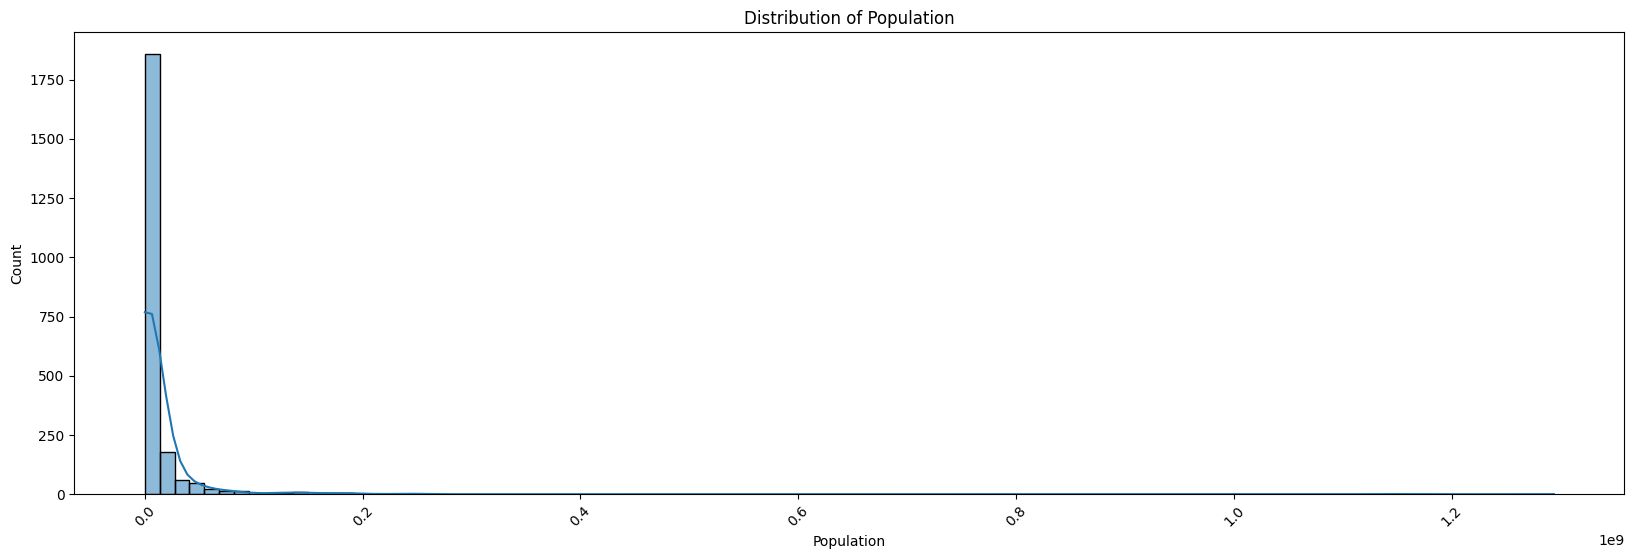

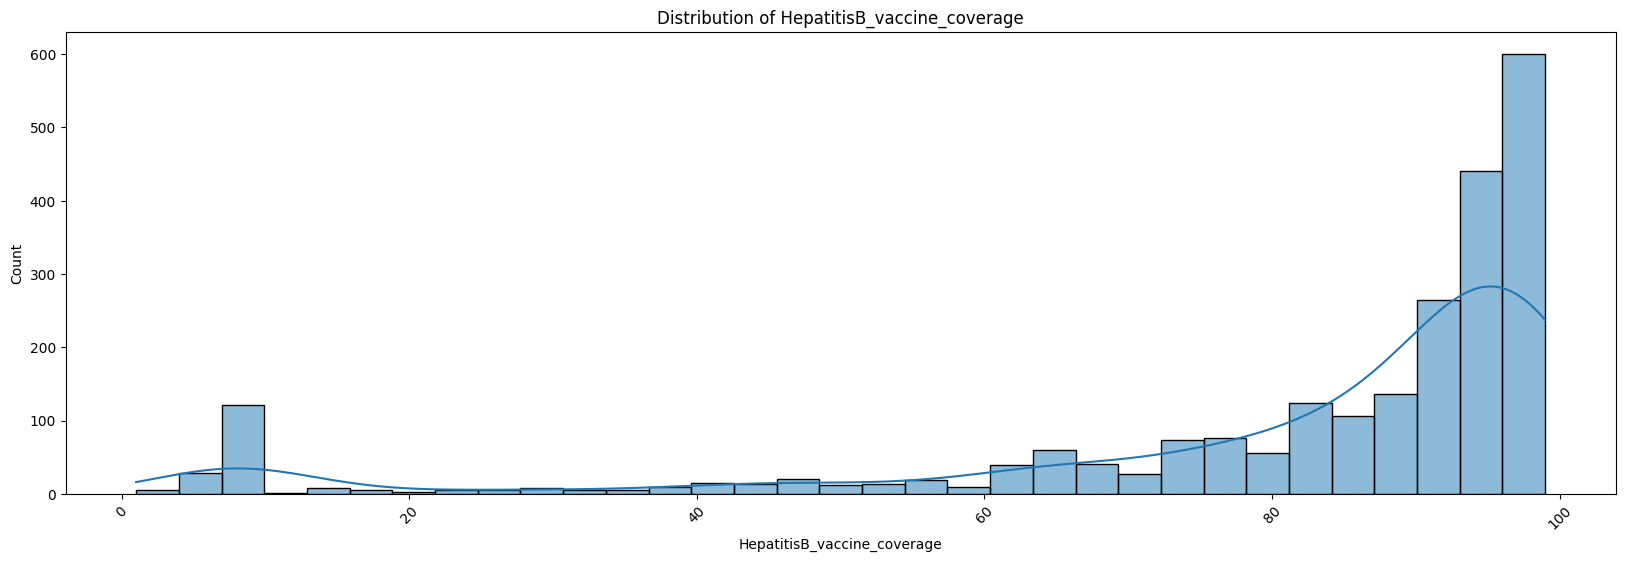

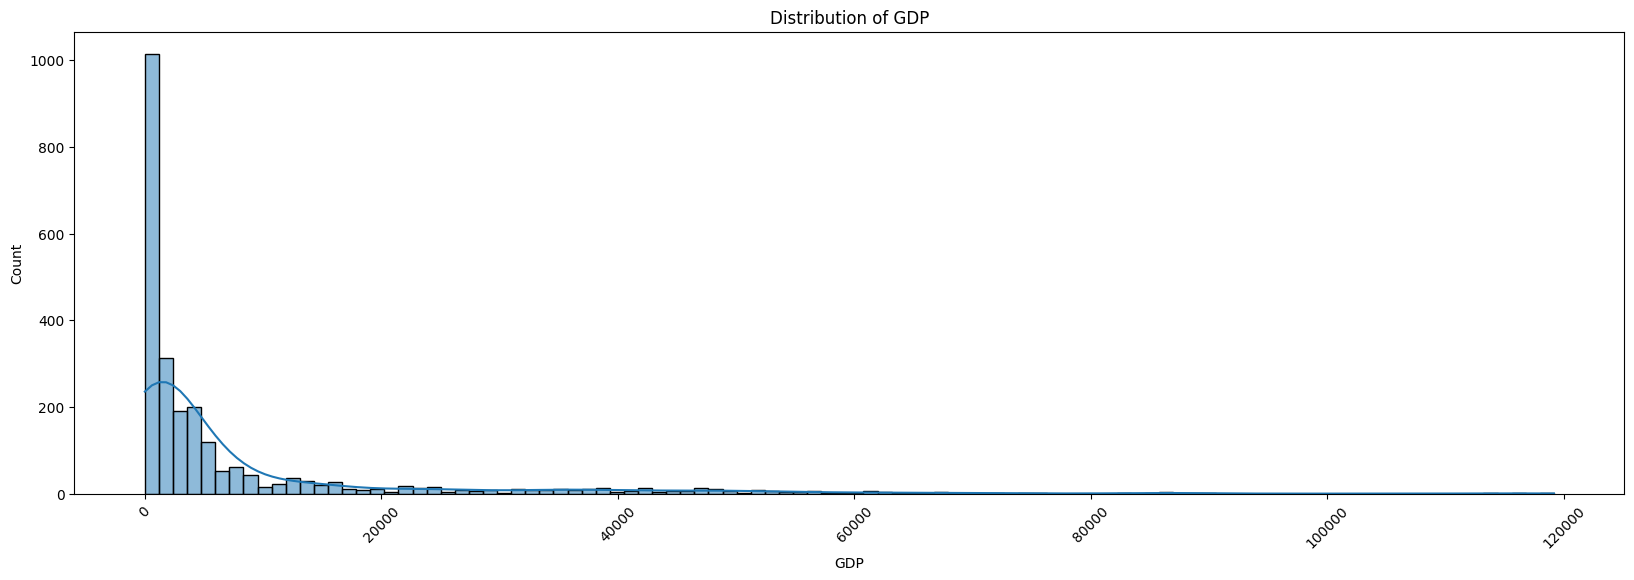

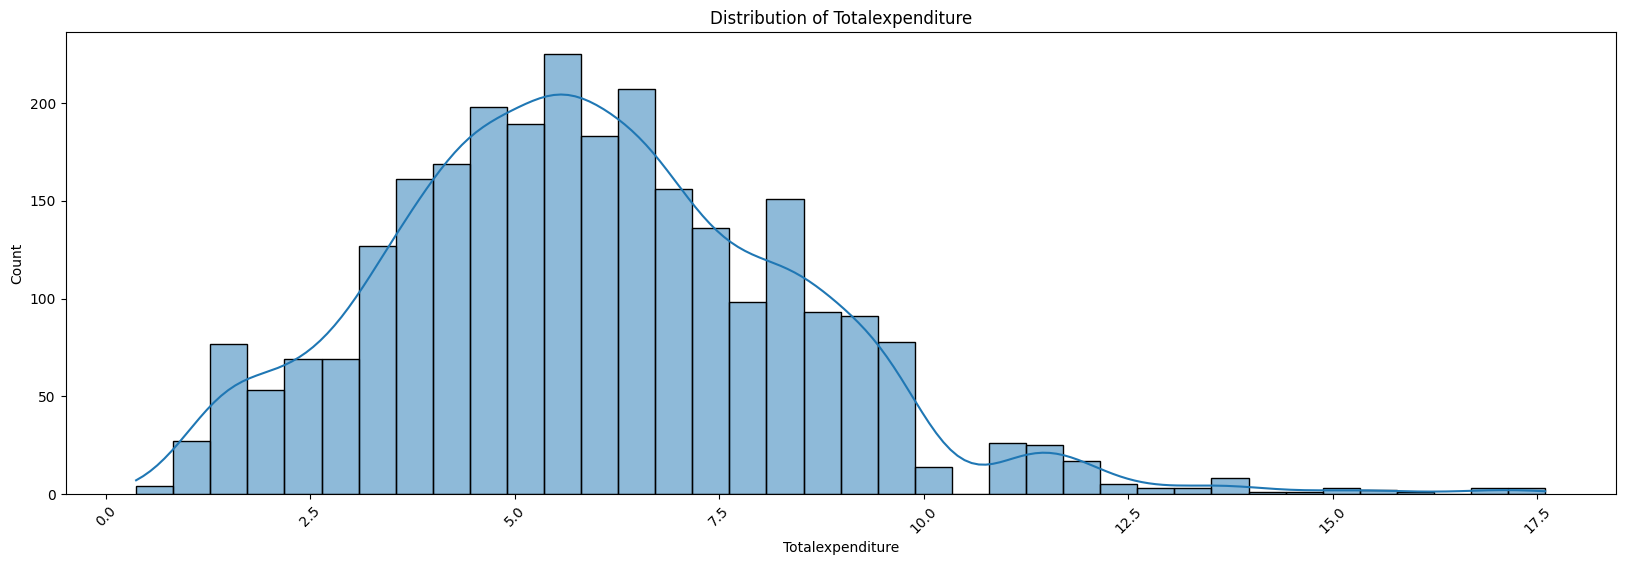

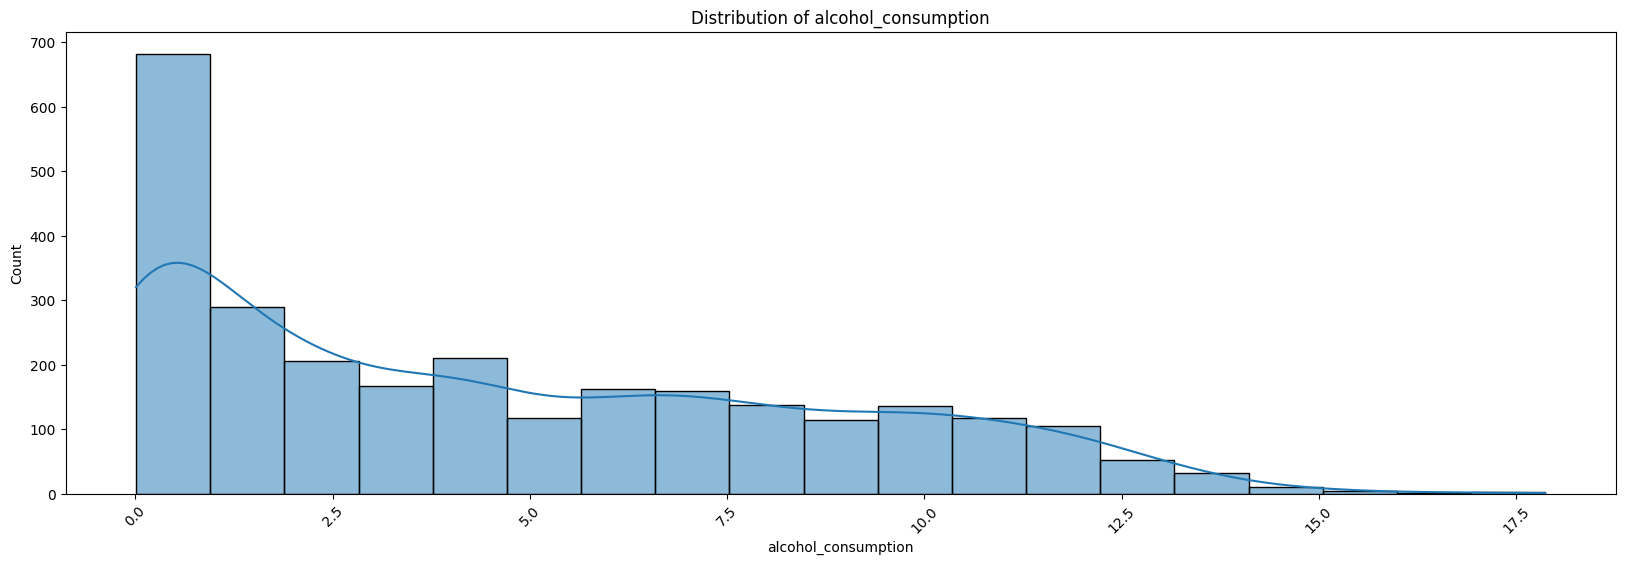

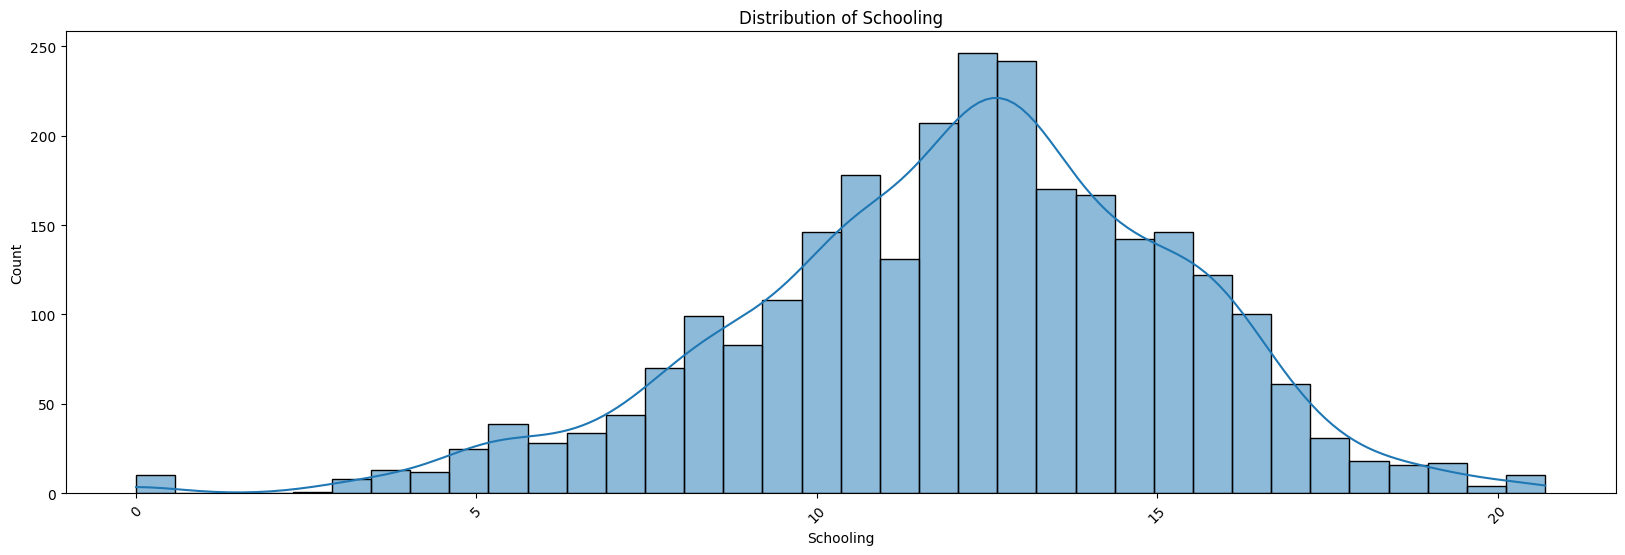

In [176]:
distribution_columns = ['Population','HepatitisB_vaccine_coverage','GDP','Totalexpenditure','alcohol_consumption','Schooling']

for col in distribution_columns:
    plt.figure(figsize=(20, 6))
    sns.histplot(data=df,x=col,kde=True)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

Missing values in numerical columns were imputed using the median because several variables exhibited strong skewness and contained extreme outliers.

In [177]:
for col in distribution_columns:
    df[col] = df[col].fillna(df[col].median())

In [178]:
df.info()

<class 'pandas.DataFrame'>
Index: 2888 entries, 0 to 2937
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      2888 non-null   str    
 1   Year                         2888 non-null   int64  
 2   Status                       2888 non-null   str    
 3   Lifeexpectancy               2888 non-null   float64
 4   AdultMortality               2888 non-null   float64
 5   infantdeaths                 2888 non-null   int64  
 6   alcohol_consumption          2888 non-null   float64
 7   HepatitisB_vaccine_coverage  2888 non-null   float64
 8   Measles                      2888 non-null   int64  
 9   BMI                          2888 non-null   float64
 10  under-fivedeaths             2888 non-null   int64  
 11  Polio_vaccine_coverage       2888 non-null   float64
 12  Totalexpenditure             2888 non-null   float64
 13  Diphtheria_vaccine_coverage  2888 

### 3.2. Find Outliers

In [179]:
numeric_cols = df.select_dtypes(include="number").columns
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR  = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        "columns": col,
        "outlier_count": len(outliers),
        "outlier_percentage": round(len(outliers) / len(df) * 100,2),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    })
outlier_df = pd.DataFrame(outlier_summary).sort_values(by="outlier_percentage", ascending=False)
print("\nOutlier summary:")
display(outlier_df)



Outlier summary:


,columns,outlier_count,outlier_percentage,lower_bound,upper_bound
6,Measles,536,18.56,-5.283750e+02,8.806250e+02
12,HIV/AIDS,526,18.21,-9.500000e-01,1.850000e+00
14,Population,443,15.34,-5.815588e+06,1.080151e+07
13,GDP,436,15.10,-5.903233e+03,1.138446e+04
8,under-fivedeaths,396,13.71,-3.900000e+01,6.500000e+01
3,infantdeaths,329,11.39,-3.150000e+01,5.250000e+01
5,HepatitisB_vaccine_coverage,317,10.98,6.100000e+01,1.170000e+02
11,Diphtheria_vaccine_coverage,292,10.11,4.950000e+01,1.255000e+02
9,Polio_vaccine_coverage,273,9.45,4.950000e+01,1.255000e+02
2,AdultMortality,87,3.01,-1.550000e+02,4.530000e+02


Outliers were detected using the IQR method. Several variables, including Population, GDP, Measles, HIV/AIDS, infant deaths, and under-five deaths, exhibited a high proportion of outliers. These observations were retained because they represent genuine differences between countries rather than data entry errors.

In [180]:
## Investigate outliers 
investigate_cols = ['Lifeexpectancy', 'AdultMortality', 'alcohol_consumption','Schooling']

for col in investigate_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ][['Country', 'Year', col]].sort_values(by=col)

    print(f"\nOutliers for {col}")
    display(outliers)


Outliers for Lifeexpectancy


,Country,Year,Lifeexpectancy
1127,Haiti,2010,36.3
2312,SierraLeone,2000,39.0
2311,SierraLeone,2001,41.0
2309,SierraLeone,2003,41.5
2308,SierraLeone,2004,42.3
1585,Malawi,2000,43.1
2307,SierraLeone,2005,43.3
1584,Malawi,2001,43.5
2921,Zambia,2000,43.8
1583,Malawi,2002,44.0



Outliers for AdultMortality


,Country,Year,AdultMortality
2789,UnitedRepublicofTanzania,2004,454.0
2793,UnitedRepublicofTanzania,2000,457.0
2406,SouthAfrica,2002,459.0
2494,Swaziland,2010,459.0
2790,UnitedRepublicofTanzania,2003,459.0
...,...,...,...
348,Botswana,2003,693.0
349,Botswana,2002,699.0
2934,Zimbabwe,2003,715.0
2932,Zimbabwe,2005,717.0



Outliers for alcohol_consumption


,Country,Year,alcohol_consumption
228,Belarus,2011,17.31
874,Estonia,2007,17.87



Outliers for Schooling


,Country,Year,Schooling
2712,Turkmenistan,2000,0.0
849,EquatorialGuinea,2000,0.0
1714,Micronesia(FederatedStatesof),2000,0.0
79,AntiguaandBarbuda,2000,0.0
78,AntiguaandBarbuda,2001,0.0
...,...,...,...
113,Australia,2014,20.4
112,Australia,2015,20.4
126,Australia,2001,20.5
124,Australia,2003,20.6


In [181]:
schooling_zero = df[df['Schooling'] == 0]

schooling_zero[['Country', 'Year', 'Status', 'Schooling']].sort_values(by='Country')
df.loc[df['Schooling'] == 0, 'Schooling'] = df['Schooling'].median()

 ### Outlier Investigation

 #### Lifeexpectancy
 Low values were observed in countries such as Haiti,
 Sierra Leone, Malawi, Zambia, Zimbabwe, and Lesotho.
 These values are historically plausible and were retained.

 #### AdultMortality:
 High values were concentrated in Southern African countries
 heavily affected by HIV/AIDS. These observations were retained.

  #### alcohol_consumption:
 Two high-consumption observations (Belarus and Estonia)
 were identified. These values are realistic and were retained.

  #### Schooling:
Outlier investigation revealed two groups of observations:

 (1) Very low values (0 years of schooling) in a small number of countries,
 which are unlikely at the country level and were treated as invalid/missing values.
 These observations were replaced with the median Schooling value.

 (2) Very high values (around 20 years) observed in developed countries such as Australia.
 These values are plausible and were retained as they reflect high educational attainment.

# 4.EDA

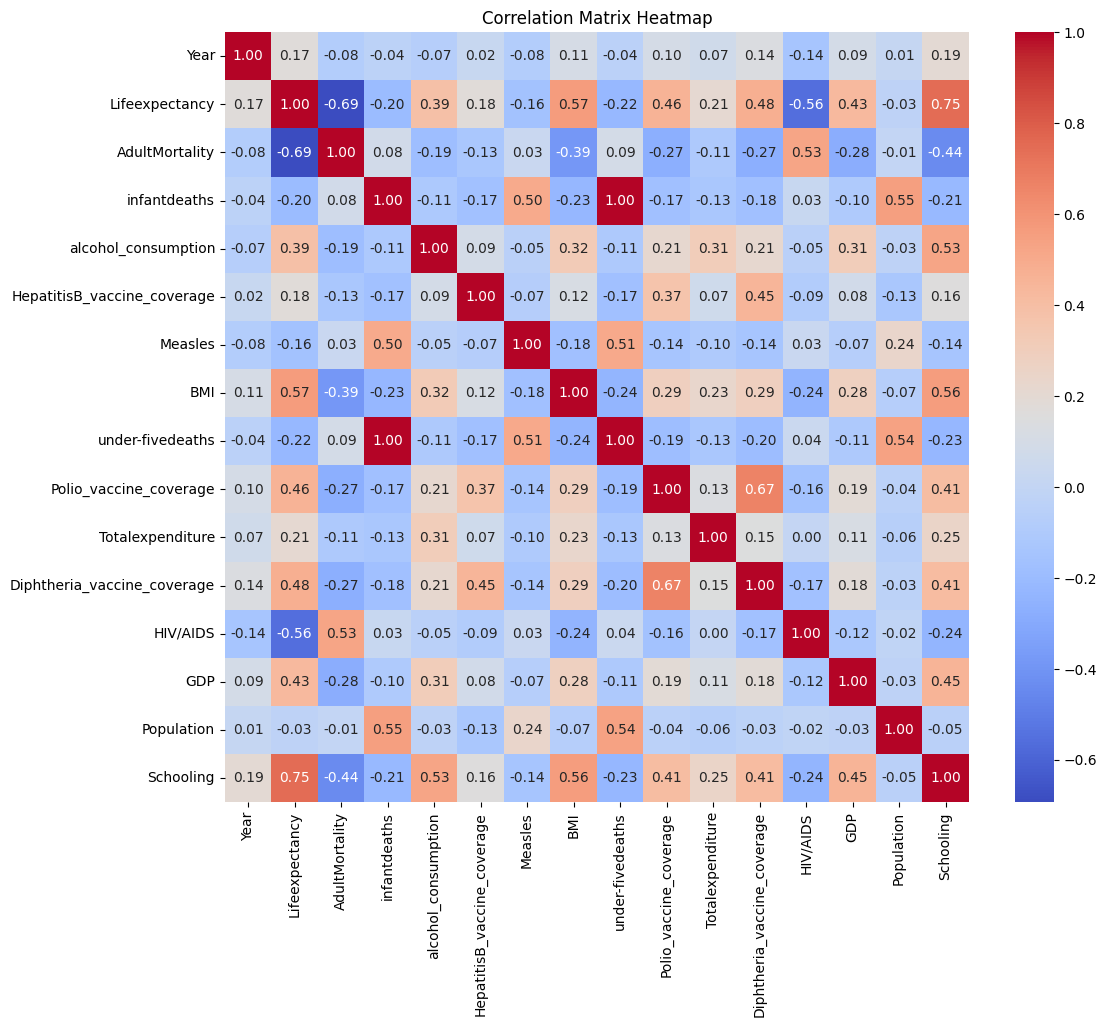

In [182]:
corr_matrix = df.select_dtypes(include="number").corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

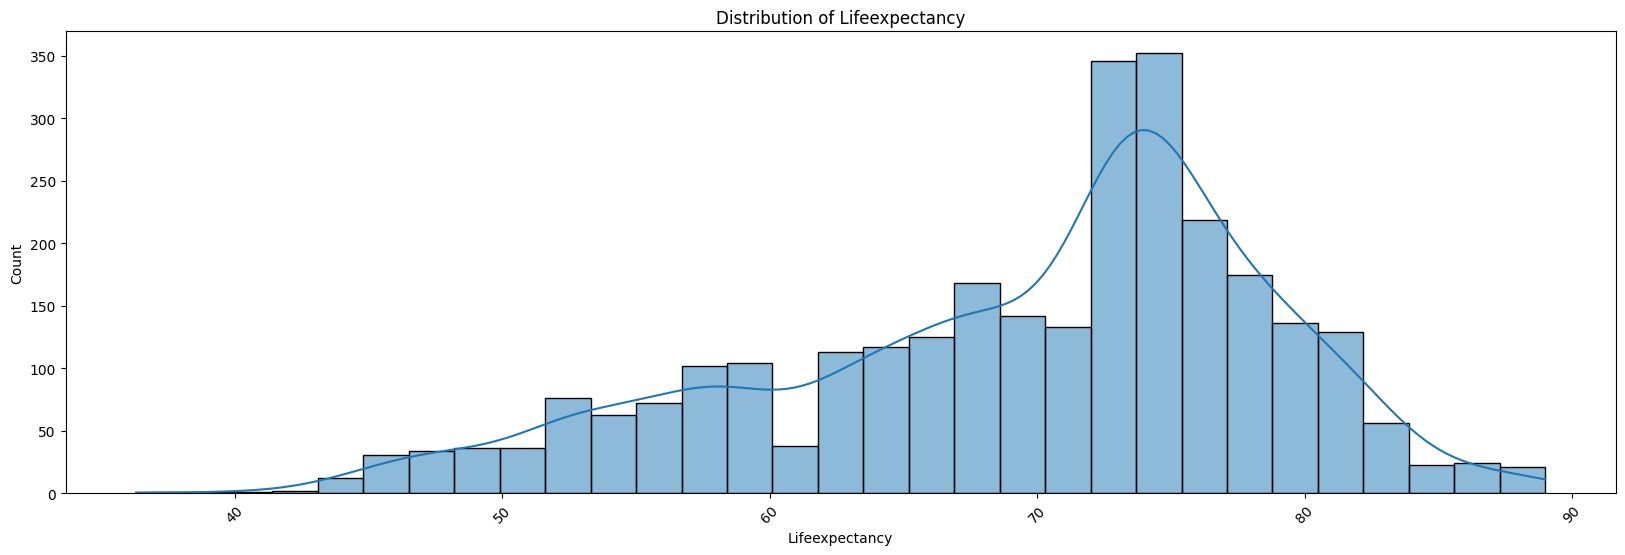

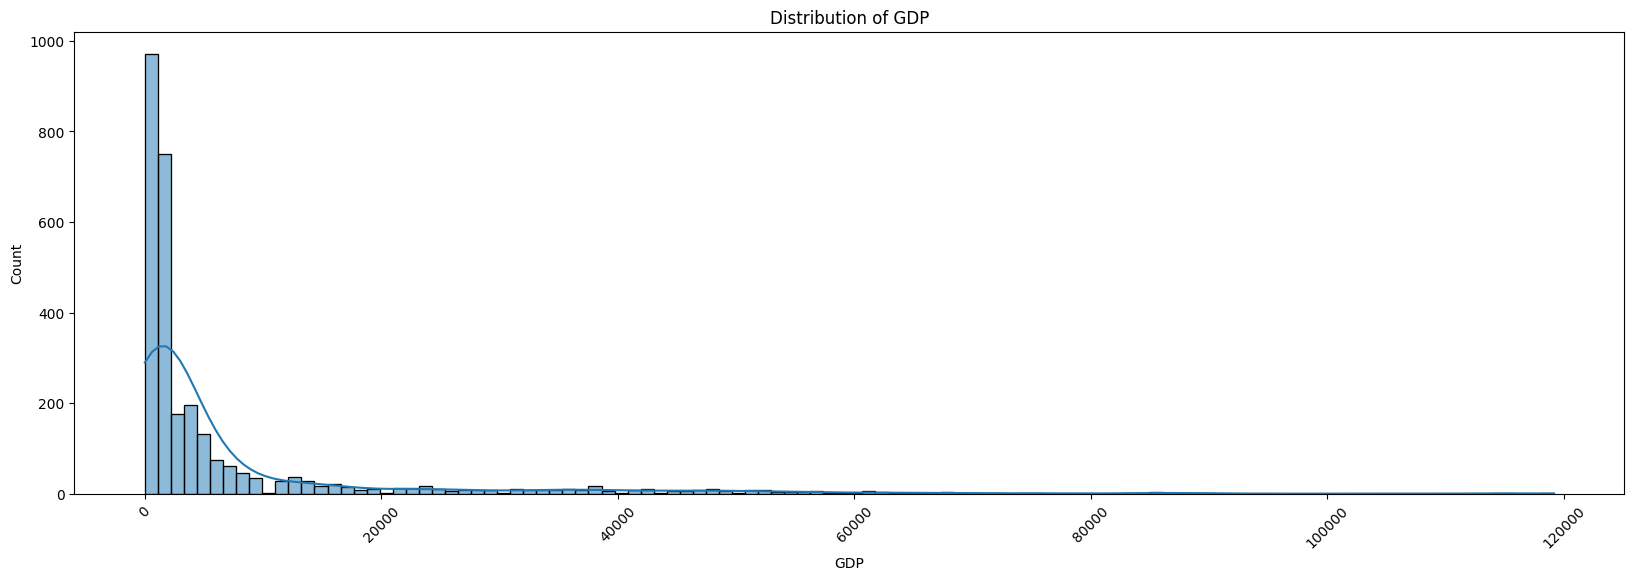

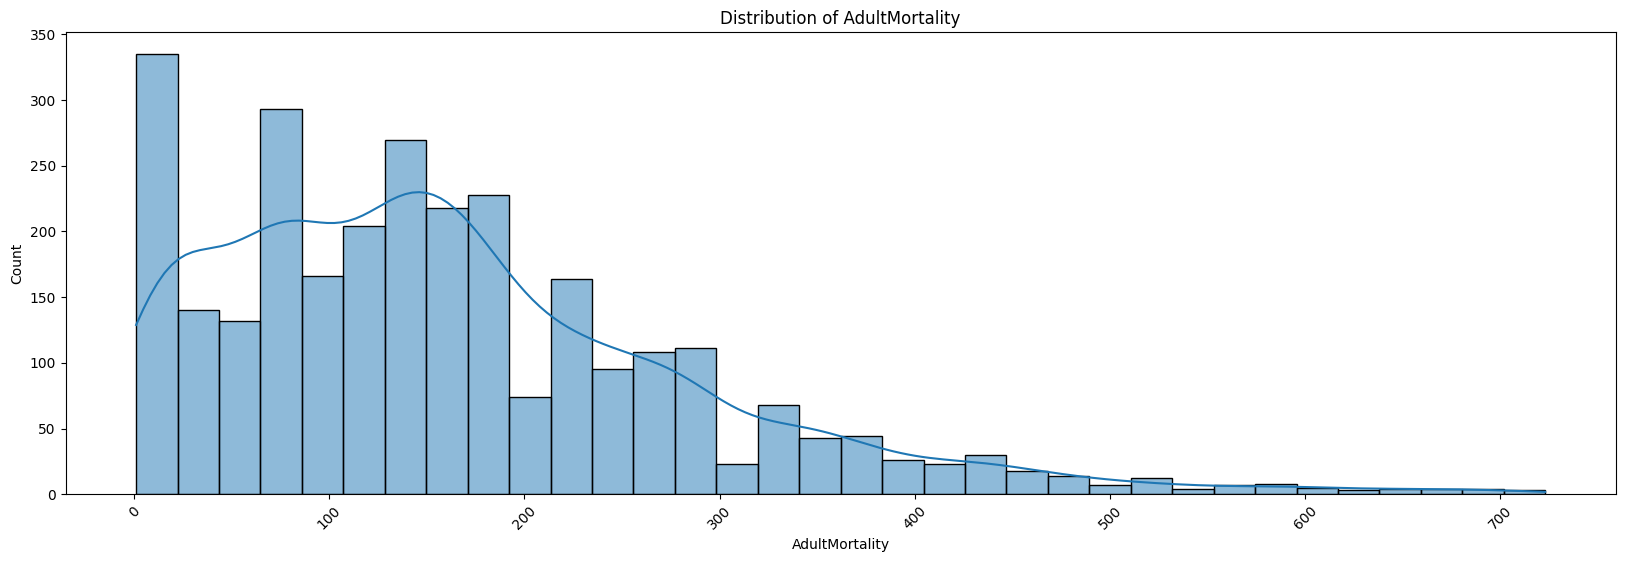

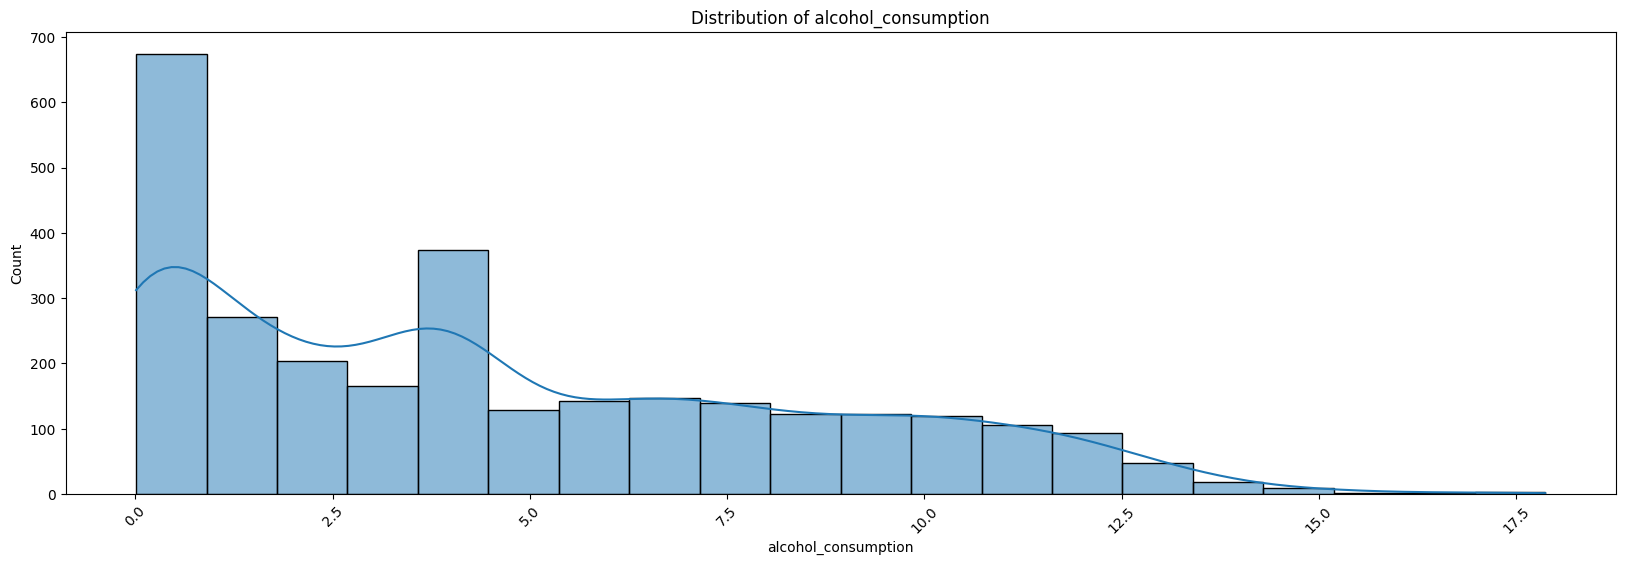

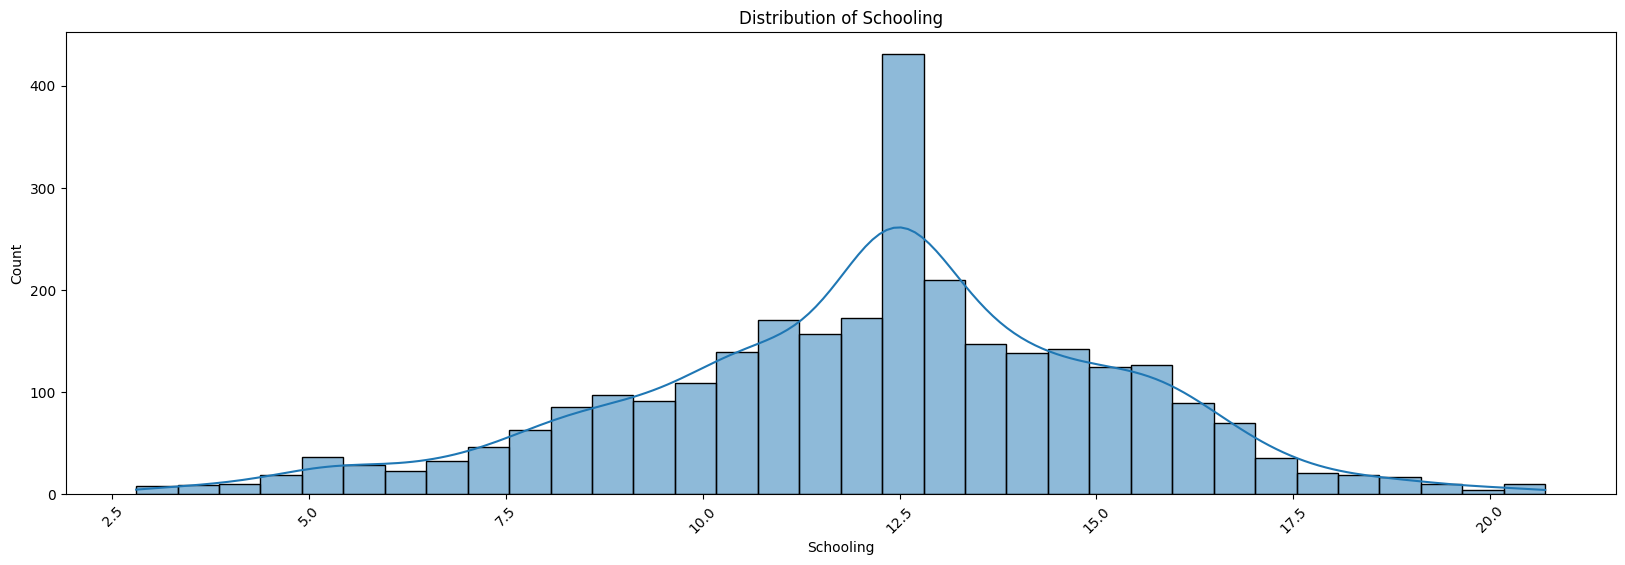

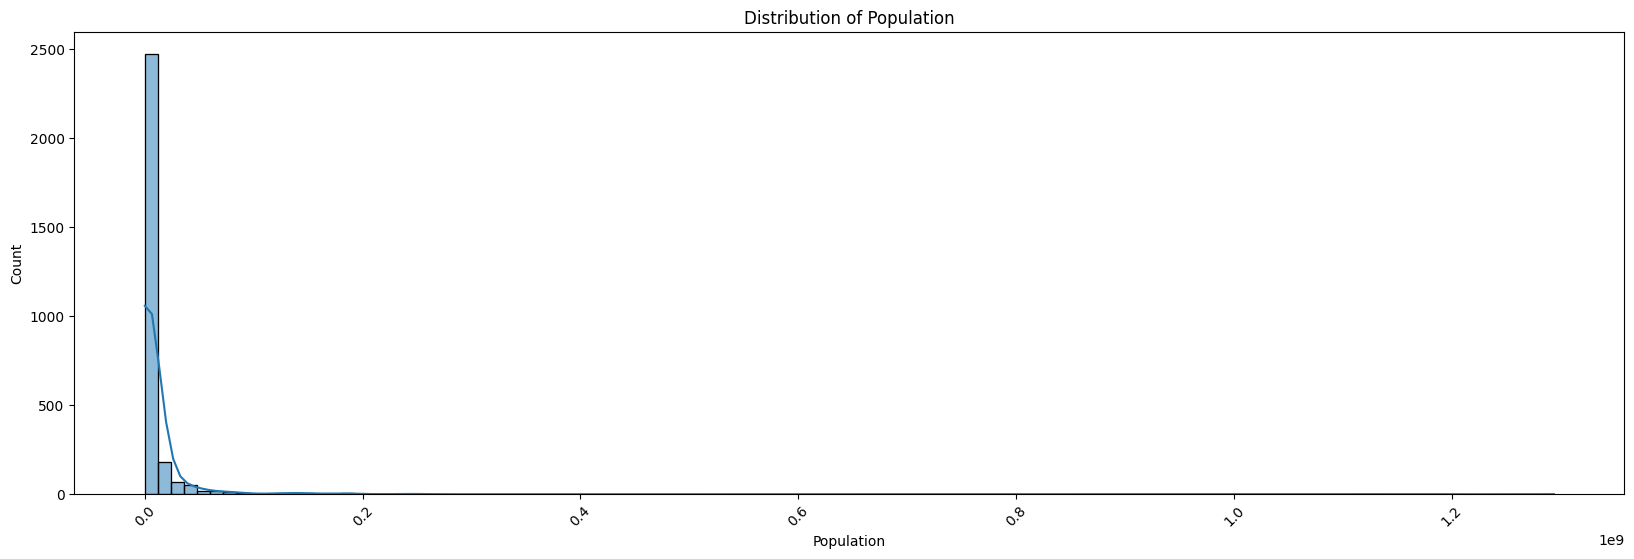

In [183]:
distribution_cols = ['Lifeexpectancy','GDP','AdultMortality','alcohol_consumption','Schooling','Population']
for col in distribution_cols:
        plt.figure(figsize=(20, 6))
        sns.histplot(data=df,x=col,kde=True)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)
        plt.show()

In [184]:
df['Status'].value_counts()

Status
Developing    2376
Developed      512
Name: count, dtype: int64

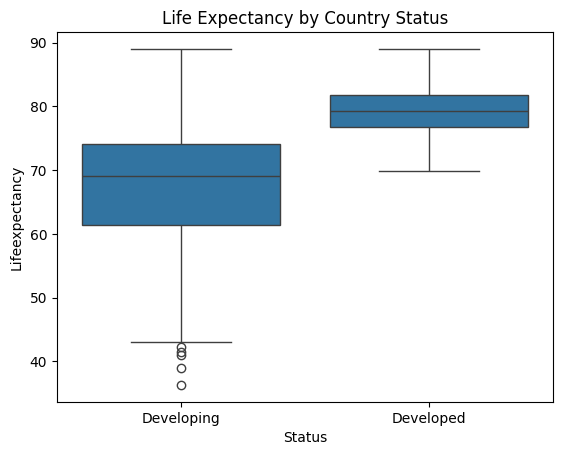

In [185]:
# Life expectancy by development status
sns.boxplot(data=df, x='Status', y='Lifeexpectancy')
plt.title('Life Expectancy by Country Status')
plt.show()

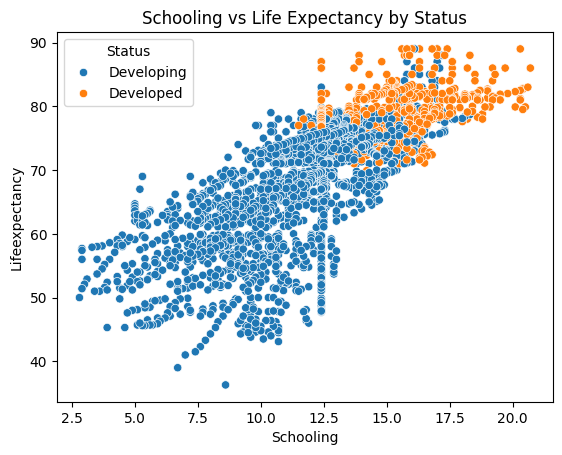

In [186]:
# Schooling vs Life Expectancy, colored by Status
sns.scatterplot(data=df, x='Schooling', y='Lifeexpectancy', hue='Status')
plt.title('Schooling vs Life Expectancy by Status')
plt.show()

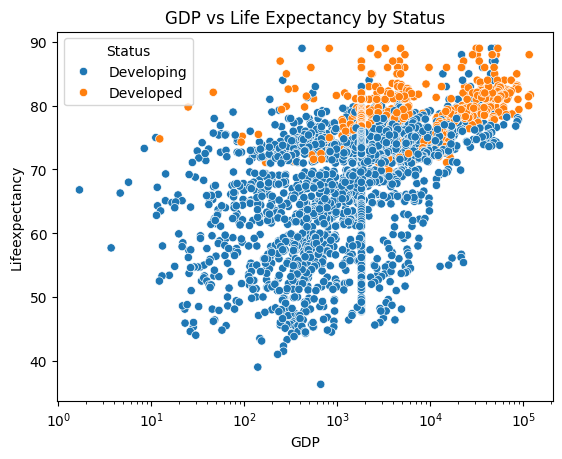

In [187]:
# GDP vs Life Expectancy, colored by Status
sns.scatterplot(data=df, x='GDP', y='Lifeexpectancy', hue='Status')
plt.xscale('log')
plt.title('GDP vs Life Expectancy by Status')
plt.show()

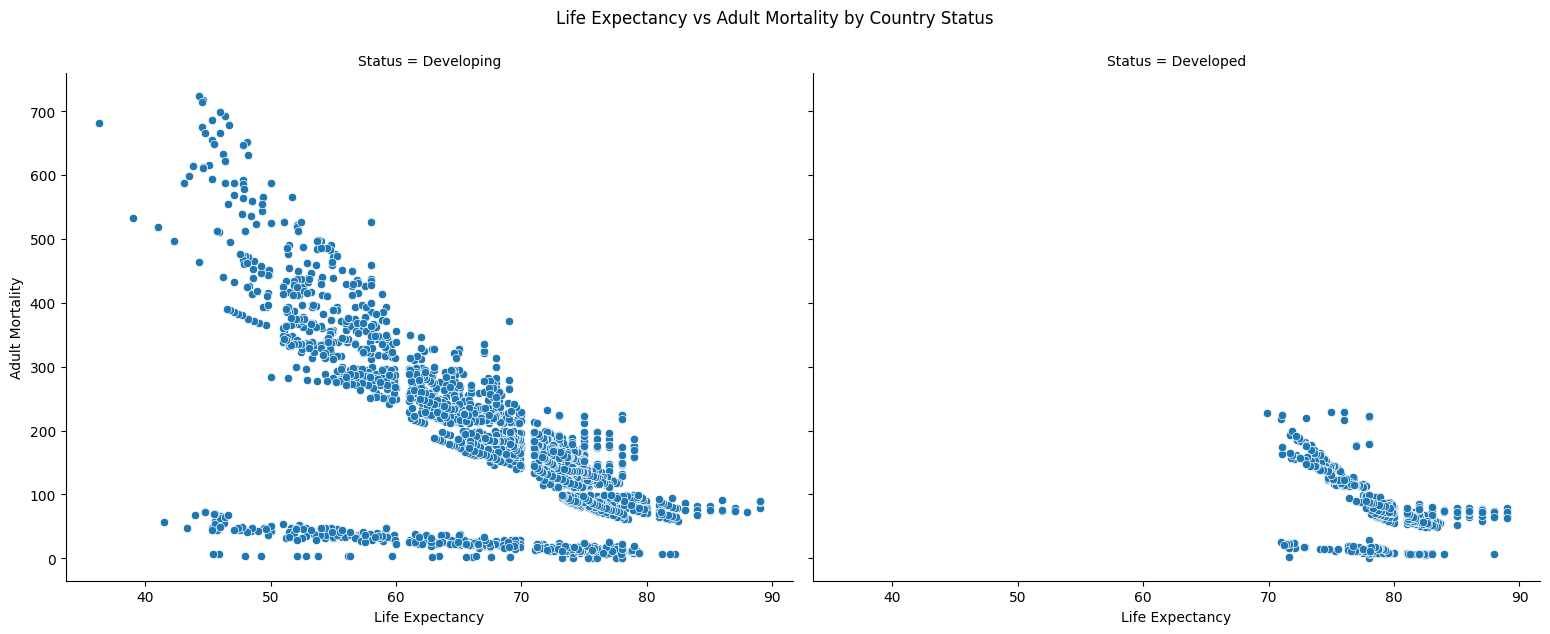

In [188]:
# Adult mortality vs Life Expectancy
g = sns.relplot(
    data=df,
    x='Lifeexpectancy',
    y='AdultMortality',
    col='Status',
    kind='scatter',
    height=6,
    aspect=1.3
)

g.fig.suptitle(
    'Life Expectancy vs Adult Mortality by Country Status',
    y=1.05
)

g.set_axis_labels('Life Expectancy', 'Adult Mortality')

plt.show()

In [189]:
life_corr = (
    df.select_dtypes(include='number')
      .corr()['Lifeexpectancy']
      .sort_values(ascending=False)
)
life_corr

Lifeexpectancy                 1.000000
Schooling                      0.745784
BMI                            0.567055
Diphtheria_vaccine_coverage    0.478194
Polio_vaccine_coverage         0.464166
GDP                            0.430491
alcohol_consumption            0.391100
Totalexpenditure               0.207656
HepatitisB_vaccine_coverage    0.175716
Year                           0.170772
Population                    -0.029596
Measles                       -0.160525
infantdeaths                  -0.197408
under-fivedeaths              -0.223172
HIV/AIDS                      -0.560382
AdultMortality                -0.693189
Name: Lifeexpectancy, dtype: float64

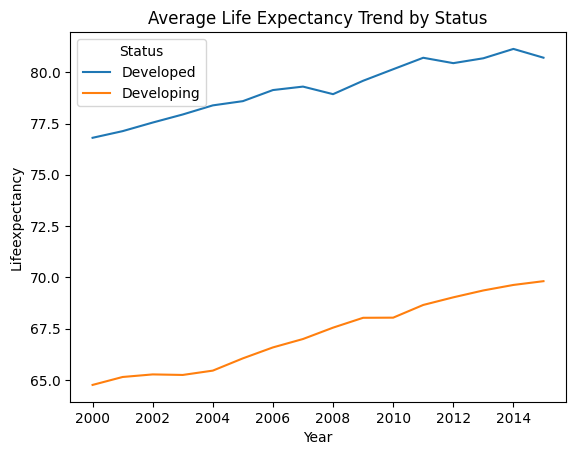

In [190]:
# Yearly trend by Status
trend = df.groupby(['Year', 'Status'])['Lifeexpectancy'].mean().reset_index()

sns.lineplot(data=trend, x='Year', y='Lifeexpectancy', hue='Status')
plt.title('Average Life Expectancy Trend by Status')
plt.show()

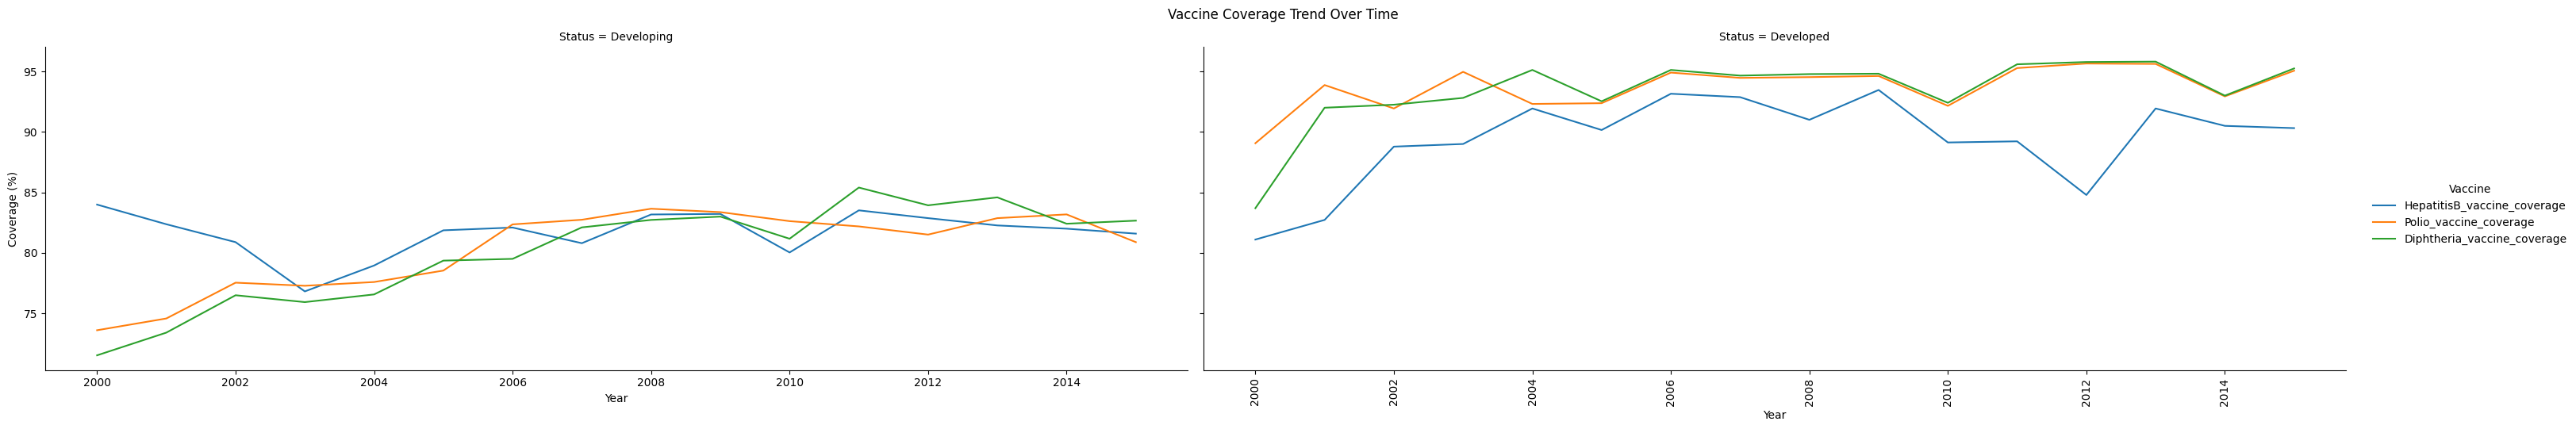

In [191]:
vaccine_cols = ['HepatitisB_vaccine_coverage', 'Polio_vaccine_coverage', 'Diphtheria_vaccine_coverage']

vaccine_long = df.melt(
    id_vars=['Country', 'Year', 'Status'],
    value_vars=vaccine_cols,
    var_name='Vaccine',
    value_name='Coverage'
)

g = sns.relplot(
    data=vaccine_long,
    x='Year',
    y='Coverage',
    hue='Vaccine',
    kind='line',
    col='Status',
    errorbar=None,
    height=5,
    aspect=3,
)

g.fig.suptitle('Vaccine Coverage Trend Over Time', y=1.03)
g.set_axis_labels('Year', 'Coverage (%)')
plt.xticks(rotation=90)
plt.show()

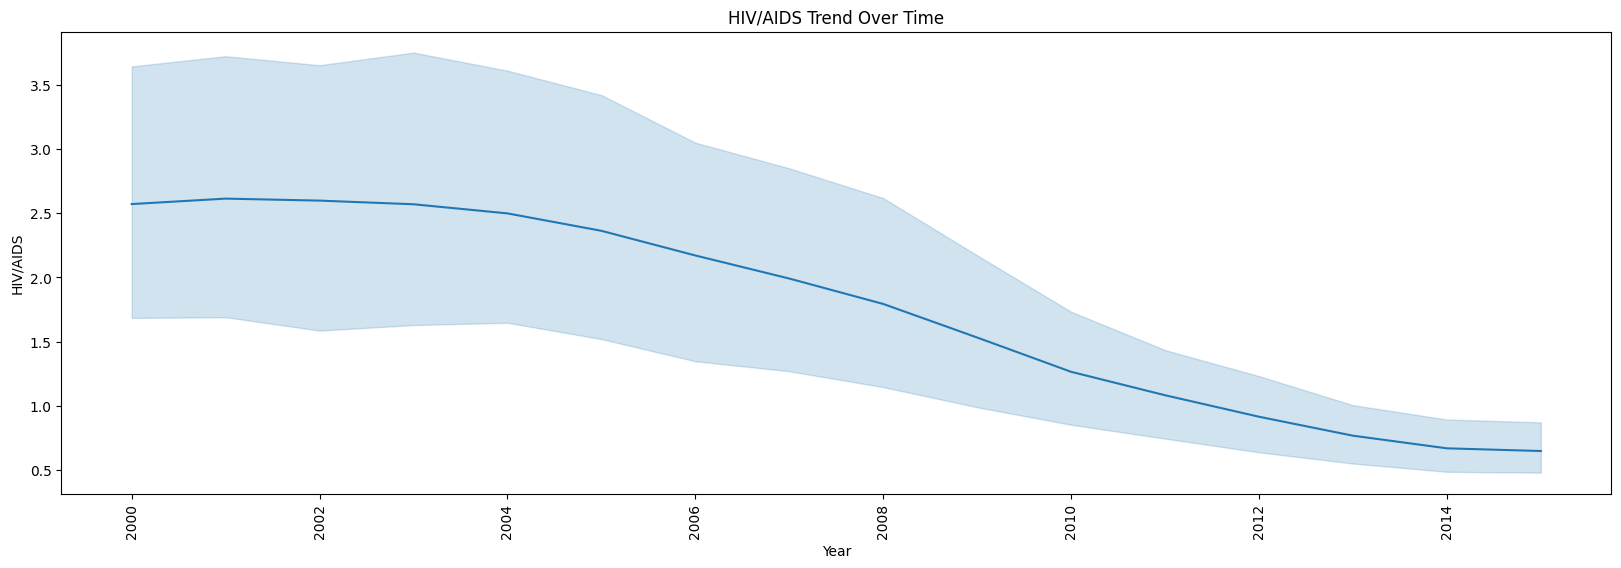

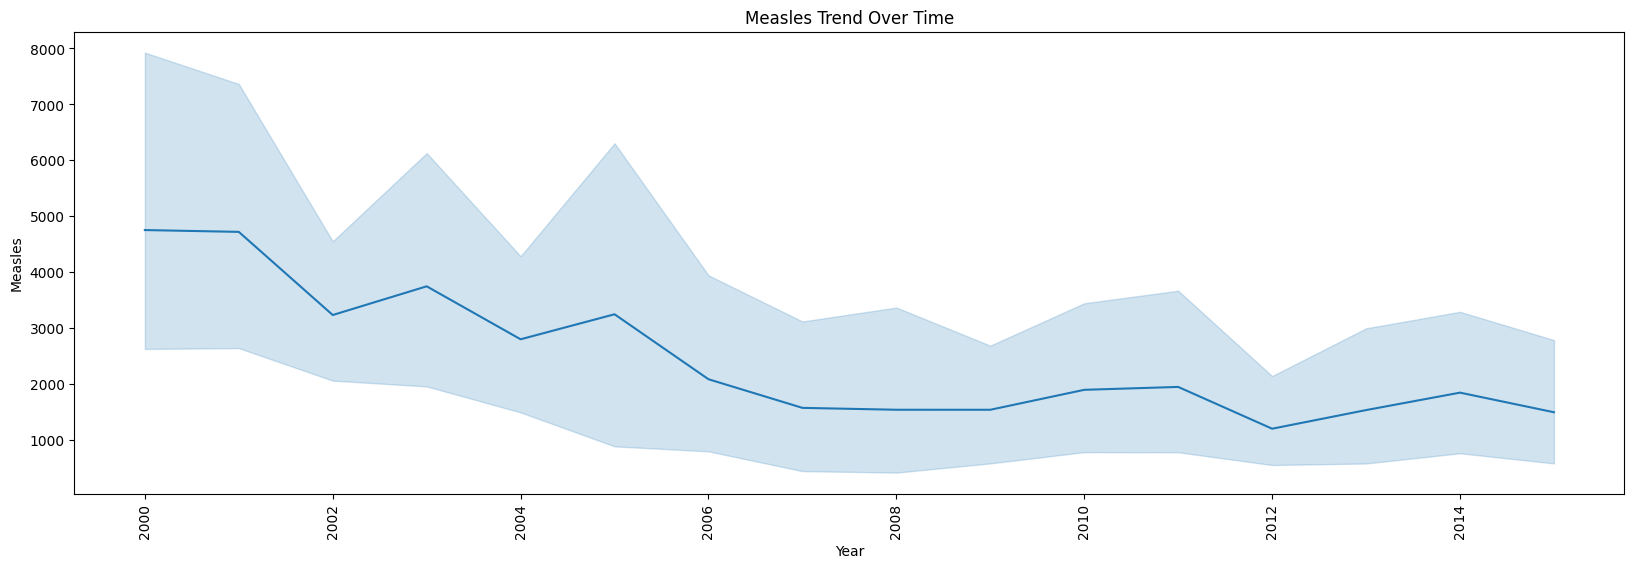

In [192]:
disease_cases = ['HIV/AIDS', 'Measles']
for col in disease_cases:
    plt.figure(figsize=(20, 6))
    
    sns.lineplot(
        data=df,
        x='Year',
        y=col
    )
    
    plt.title(f'{col} Trend Over Time')
    plt.xlabel('Year')
    plt.ylabel(col)
    plt.xticks(rotation=90)
    plt.show()

## EDA Summary

### Dataset Overview
The dataset contains country-level health, socioeconomic, vaccination, and mortality indicators from 2000 to 2015. After cleaning, the dataset includes both developed and developing countries, with a much larger number of observations from developing countries.

### Country Status Distribution
The dataset is imbalanced by country status:
- Developing: 2,376 records
- Developed: 512 records

This means most observations come from developing countries, which should be considered when interpreting overall trends.

### Life Expectancy by Status
Developed countries generally show higher life expectancy than developing countries. The boxplot shows that developed countries have a higher median life expectancy and less variation, while developing countries have a wider spread and several low-life-expectancy outliers.

### Correlation with Life Expectancy
The strongest positive correlations with Lifeexpectancy were:
- Schooling: 0.72
- BMI: 0.57
- Diphtheria vaccine coverage: 0.48
- Polio vaccine coverage: 0.46
- GDP: 0.43

The strongest negative correlations were:
- AdultMortality: -0.69
- HIV/AIDS: -0.56
- under-fivedeaths: -0.22
- infantdeaths: -0.20
- Measles: -0.16

This suggests that education, nutrition, vaccination coverage, and economic development are positively associated with life expectancy, while mortality and disease burden are negatively associated with life expectancy.

### Schooling vs Life Expectancy
The scatterplot shows a clear positive relationship between Schooling and Lifeexpectancy. Countries with higher average years of schooling tend to have higher life expectancy. Developed countries are concentrated in the higher schooling and higher life expectancy range.

### GDP vs Life Expectancy
GDP shows a positive relationship with life expectancy. A log scale was used because GDP is highly right-skewed. Developed countries generally have higher GDP and higher life expectancy, while developing countries show more variation.

### Adult Mortality vs Life Expectancy
AdultMortality has a strong negative relationship with Lifeexpectancy. Countries with higher adult mortality generally have lower life expectancy. This pattern is especially visible among developing countries.

### Life Expectancy Trend Over Time
Average life expectancy increased over time for both developed and developing countries from 2000 to 2015. Developed countries consistently had higher average life expectancy, but developing countries also showed steady improvement.

### Vaccination Coverage Trend
Hepatitis B, Polio, and Diphtheria vaccination coverage generally increased over time, especially among developing countries. Developed countries already had high vaccination coverage, so their trends were more stable.

### Disease Trends
HIV/AIDS showed a decreasing trend over time, suggesting improvement in disease control and treatment access. Measles cases also generally declined, although some fluctuations remained, likely due to outbreaks in specific years or countries.

### Overall Insight
Life expectancy appears to be strongly associated with education, adult mortality, HIV/AIDS burden, vaccination coverage, BMI, and GDP. Developed countries generally perform better across these indicators, but developing countries showed clear improvement over time.

In [193]:
df.to_csv("../data/processed/life_expectancy_clean.csv", index=False)